In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X shape: (200, 2)
y shape: (200,)
First 5 X values:
 [[3.40279431 0.59814894]
 [1.80763904 2.30154734]
 [3.46564877 1.7742237 ]
 [6.32271856 5.17276906]
 [2.21409374 0.75426122]]
First 5 y values:
 [0. 0. 0. 1. 0.]


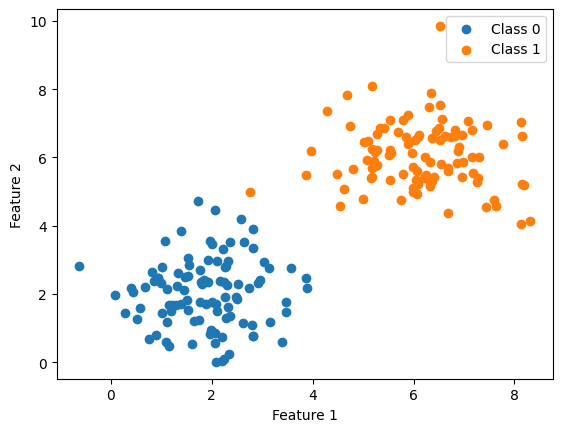

In [6]:

np.random.seed(42)

n = 100
# Class 0
X0 = np.random.randn(n, 2) + np.array([2, 2])
y0 = np.zeros(n)
# Class 1
X1 = np.random.randn(n, 2) + np.array([6, 6])
y1 = np.ones(n)
# Combine
X = np.vstack((X0, X1))
y = np.hstack((y0, y1))
# Shuffle dataset
indices = np.random.permutation(len(X))
X = X[indices]
y = y[indices]
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 X values:\n", X[:5])
print("First 5 y values:\n", y[:5])

# Visualize
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [7]:
def step_function(x):
    return 1 if x >= 0 else 0

In [8]:
def perceptron(X, y, learning_rate=0.1, n_epochs=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    for epoch in range(n_epochs):
        for idx, x_i in enumerate(X):
            linear_output = np.dot(x_i, weights) + bias
            y_predicted = step_function(linear_output)

            # Update weights and bias
            update = learning_rate*(y[idx]-y_predicted)
            weights += update * x_i
            bias += update

    return weights, bias

In [9]:

w, b = perceptron(X, y, learning_rate=0.1, n_epochs=1000)
m=-w[0]/w[1]
c=-b/w[1]

Y = m*X[:,0]+c
Y_i=-X[:,0]-1

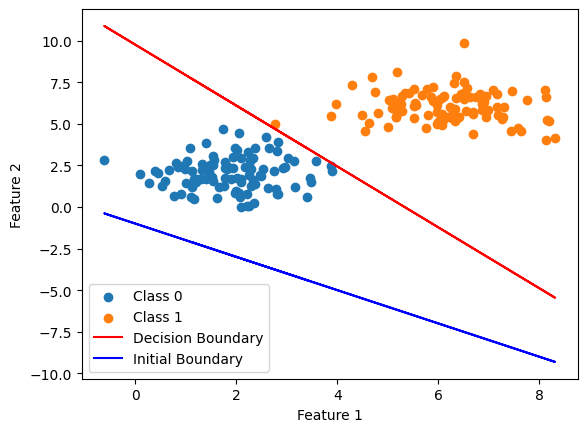

In [10]:
# Visualize decision boundary
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1")
plt.plot(X[:,0], Y, color='red', label='Decision Boundary') 
plt.plot(X[:,0], Y_i, color='blue', label='Initial Boundary')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

#Loss Function

In [11]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=15)

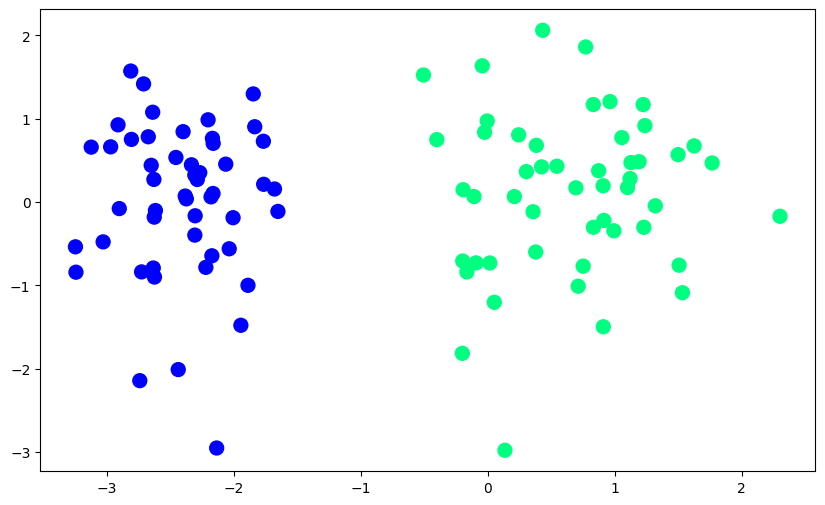

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [2]:
def loss_function(X, y):
    n_samples = X.shape[0]
    lr=0.1
    weights = np.ones(X.shape[1])
    bias = 1
    for epoch in range(1000):
        loss=0
        for idx in range(n_samples):

            z=np.dot(X[idx],weights)+bias

            if z*y[idx]<0:
                weights+=lr*y[idx]*X[idx]
                bias+=lr*y[idx]
                loss+=1
        if loss==0:
            print("Converged at epoch:", epoch)
            break
    return weights, bias

In [16]:
weights,bias = loss_function(X,y)

Converged at epoch: 2


In [17]:
w1,w2,b = weights[0],weights[1],bias

In [18]:
m = -(w1/w2)
c = -(b/w2)

print(m,c)

-4.531321834268464 -5.851870329508209


(-3.0, 2.0)

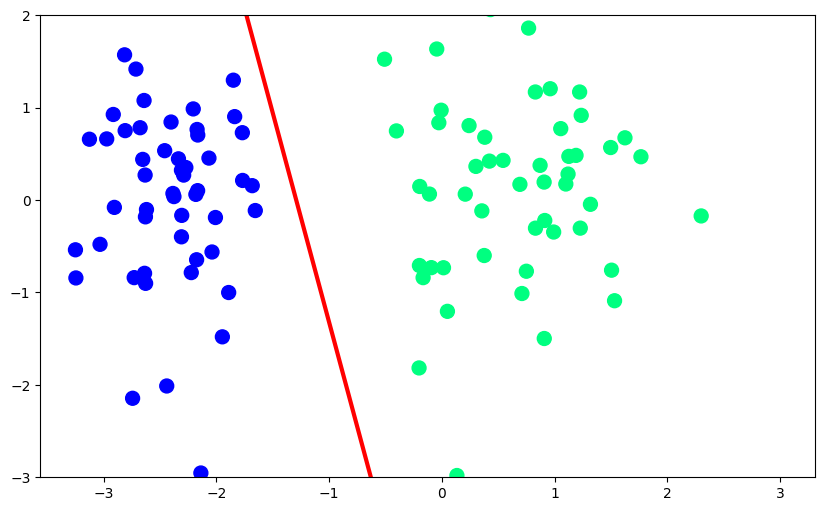

In [20]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + c

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)